# $\nu$-SVM deconvolver

## Imports and utils

In [119]:
from pathlib import Path
import sys
import os

from tqdm.notebook import tqdm
import json
import pickle
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from sklearn.svm import NuSVR
from sklearn.preprocessing import scale
from scipy.stats import pearsonr

sys.path.append(str(Path(os.getcwd())))
from methyldl.deconvolution.least_squares_deconvolvers import NNLSDeconvolver
from methyldl.deconvolution.evaluation import compute_deconvolution_metrics

In [54]:
def plot_mixtures_pred_vs_true(
    ground_truth_mixture: np.ndarray,
    predicted_mixtures: list[np.ndarray],
    predicted_mixture_labels: list[str],
    width: float = 0.2,
    title: str = "Predicted Mixtures vs Ground Truth Mixture",
    ctype_names: list[str] = None,
):
    """
    Plot the predicted mixtures against the ground truth mixture for a single sample.
    The function creates a bar plot where the x axis represents the cell types and the y axis represents the mixture proportions.
    Each predicted mixture is plotted as a separate bar. The ground truth mixture is plotted as red dots for each cell type.

    Args:
        ground_truth_mixture: A 1D array of shape (n_cell_types,) representing the true mixture proportions.
        predicted_mixtures: A list of 1D arrays, each of shape (n_cell_types,), representing the predicted mixture proportions from different models.
        predicted_mixture_labels: A list of strings representing the labels for each predicted mixture (e.g., model names).
    """
    assert len(predicted_mixtures) == len(
        predicted_mixture_labels
    ), "Number of predicted mixtures must match number of labels"
    assert all(
        pred.shape == ground_truth_mixture.shape for pred in predicted_mixtures
    ), "All predicted mixtures must have the same shape as the ground truth mixture"
    plt.figure(figsize=(8, 6))
    n_cell_types = len(ground_truth_mixture)
    n_predicted_mixtures = len(predicted_mixtures)
    x = np.arange(n_cell_types)  # start of the the label locations
    x_center = (
        x + width * (n_predicted_mixtures - 1) / 2
    )  # middle of the group of bars for each cell type

    # Plot the ground truth mixture as red dots
    plt.scatter(
        x_center, ground_truth_mixture, color="red", zorder=-1, label="Ground Truth"
    )

    # Plot each predicted mixture as a bar
    for i, (predicted_mixture, label) in enumerate(
        zip(predicted_mixtures, predicted_mixture_labels)
    ):
        plt.bar(x + i * width, predicted_mixture, width, label=label, alpha=0.7)

    # plot the cell types names on the x axis, rotated by 90 degrees
    if ctype_names is not None:
        plt.xticks(x_center, ctype_names, rotation=90)
    plt.ylabel("Mixture Proportions")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

## Data loading and preprocessing

ios_full_matrices:
- "proportions_train": (100000, 39) - ctype proportions for training samples
- "proportions_valid": (100000, 39) - ctype proportions for validation samples
- "proportions_test": (100000, 39) - ctype proportions for test samples
- "features_train": (100000, 39, 39) - feature matrices for training samples
- "features_valid": (100000, 39, 39) - feature matrices for validation samples
- "features_test": (100000, 39, 39) - feature matrices for test samples

Pure profiles: 39x:
- 0 : ctype proportions
- 1: {"train" : pure feature matrix, "valid": pure feature matrix, "test": pure feature matrix}:


In [29]:
N_CELL_TYPES = 39

In [5]:
ROOT_PATH = Path("../Data/extended_proportions/pseudobulk/dismir_soft_labels_with_pooling")
ios_full_matrices = np.load(ROOT_PATH / "ios_full_matrices.npz")
pure_profiles = pickle.load(open(ROOT_PATH / "pure_profiles.pkl", "rb"))

In [46]:
val_feature_matrices = ios_full_matrices["features_valid_uniform_multinomial"]
val_feature_matrices = val_feature_matrices.reshape(val_feature_matrices.shape[0], -1)
val_feature_matrices.shape

(100000, 1521)

In [47]:
val_proportions = ios_full_matrices["proportions_valid"]
val_proportions.shape

(100000, 39)

In [41]:
pred_columns = [f"prediction_{i}_wavg" for i in range(N_CELL_TYPES)]
reference_matrix = np.stack(
    [pure_profiles[i][1]["train"][pred_columns].to_numpy().reshape(-1) for i in range(len(pure_profiles))], axis=0
)
reference_matrix.shape

(39, 1521)

In [56]:
with open("../App/labels_dict.json", "r", encoding="utf-8") as f:
    labels_dict = json.load(f)

## Reference deconvolver

In [67]:
nnls_deconvolver = NNLSDeconvolver()
nnls_deconvolver.fit(X = reference_matrix, y = np.arange(N_CELL_TYPES))

NNLSDeconvolver()

## $\nu$-SVM deconvolution

In [111]:
def nu_svm_deconvolve_single_sample(
    x: np.ndarray,
    reference_matrix: np.ndarray,
    nu: float = 0.005,
    kernel: str = "linear",
    scale_data: bool = True,
)-> np.ndarray:
    """
    Deconvolve a single bulk sample x using the reference matrix.

    Args:
        x (np.ndarray): flattenened feature matrix for one sample (F,)
        reference_matrix (np.ndarray): reference signature matrix (C, F)
    """
    if scale_data:
        x = (x - x.mean()) / x.std()
        reference_matrix = scale(reference_matrix, axis=1)

    model = NuSVR(nu=nu, C=1.0, kernel=kernel)
    model.fit(reference_matrix.T, x)  # reference_matrix.T is (F, C)

    coef = (model.dual_coef_ @ model.support_vectors_).flatten()  # (C,)
    coef = np.maximum(coef, 0)  # non-negativity

    total = coef.sum()
    if total > 0:
        f = coef / total
    else:
        f = coef  # degenerate case: all zeros

    return f

In [ ]:
pred_prop = nu_svm_deconvolve_single_sample(
    x=val_feature_matrices[0],  # first sample
    reference_matrix=reference_matrix,
    nu=0.005,
    kernel="linear",
    scale_data=True,
)

In [114]:
nnls_pred_prop = nnls_deconvolver.predict(val_feature_matrices[0].reshape(1, -1))[0]

Predicting with NNLS sequentially: 100%|██████████| 1/1 [00:00<00:00, 214.83it/s]


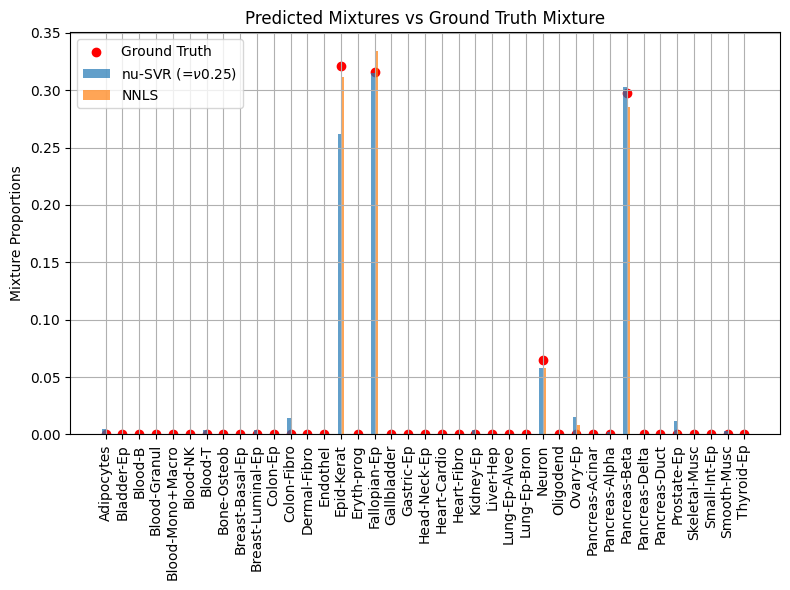

In [115]:
plot_mixtures_pred_vs_true(
    ground_truth_mixture=val_proportions[0],
    predicted_mixtures=[pred_prop, nnls_pred_prop],
    predicted_mixture_labels=[r"nu-SVR (=$\nu$" + f"{best_nu})", "NNLS"],
    ctype_names=[labels_dict[str(i)] for i in range(N_CELL_TYPES)],
)

### Manual investigation of the effect of $\nu$ on the predictions

In [136]:
# manual investigation of the effect of nu
scale_data = True
sample_idx = 5
x = val_feature_matrices[sample_idx]
if scale_data:
    x_ = (x - x.mean()) / x.std()
    reference_matrix_ = scale(reference_matrix, axis=1)
else:
    x_ = x
    reference_matrix_ = reference_matrix

nu_values = [0.001, 0.01, 0.1, 0.25, 0.5, 0.75]
predictions = np.zeros((len(nu_values), N_CELL_TYPES))
support_vectors_counts = []

for i, nu in tqdm(enumerate(nu_values), total=len(nu_values)):
    model = NuSVR(nu=nu, C=1.0, kernel="linear")
    model.fit(reference_matrix_.T, x_)  # reference_matrix.T is (F, C)

    coef = (model.dual_coef_ @ model.support_vectors_).flatten()  # (C,)
    coef = np.maximum(coef, 0)  # non-negativity

    total = coef.sum()
    if total > 0:
        f = coef / total
    else:
        f = coef  # degenerate case: all zeros

    predictions[i] = f

    support_vectors_counts.append(len(model.support_))

  0%|          | 0/6 [00:00<?, ?it/s]

In [137]:
nnls_pred_prop = nnls_deconvolver.predict(x.reshape(1, -1))[0]

Predicting with NNLS sequentially: 100%|██████████| 1/1 [00:00<00:00, 131.04it/s]


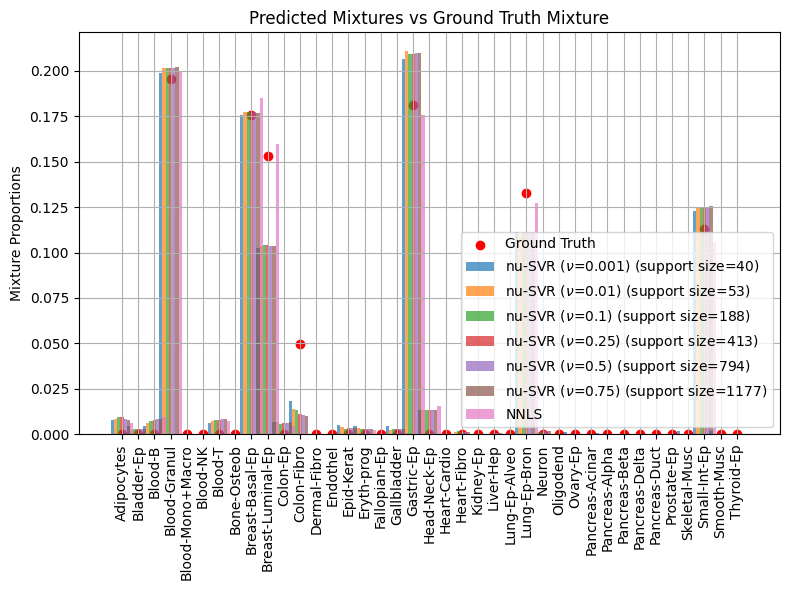

In [138]:
plot_mixtures_pred_vs_true(
    ground_truth_mixture=val_proportions[sample_idx],
    predicted_mixtures=[predictions[i] for i in range(len(nu_values))] + [nnls_pred_prop],
    predicted_mixture_labels=[r"nu-SVR ($\nu$=" + f"{nu})"+ f" (support size={support_vectors_counts[i]})" for i, nu in enumerate(nu_values)] + ["NNLS"],
    ctype_names=[labels_dict[str(i)] for i in range(N_CELL_TYPES)],
)

### Large scale evaluation

In [ ]:
n_subset = 1000
nu = 0.005
samples_idx = np.random.choice(val_feature_matrices.shape[0], size=n_subset, replace=False)
predictions_nusvm = np.zeros((n_subset, N_CELL_TYPES))
for i, idx in tqdm(enumerate(samples_idx), total=n_subset):
    x = val_feature_matrices[idx]
    pred_prop = nu_svm_deconvolve_single_sample(
        x=x,
        reference_matrix=reference_matrix,
        nu=nu,
        kernel="linear",
        scale_data=True,
    )
    predictions_nusvm[i] = pred_prop

  0%|          | 0/1000 [00:00<?, ?it/s]

In [127]:
nnls_predictions = nnls_deconvolver.predict(val_feature_matrices[samples_idx])

Predicting with NNLS sequentially: 100%|██████████| 1000/1000 [00:03<00:00, 264.51it/s]


In [128]:
nusvm_metrics = compute_deconvolution_metrics(
    pred=predictions_nusvm,
    target=val_proportions[samples_idx],
)
nnls_metrics = compute_deconvolution_metrics(
    pred=nnls_predictions,
    target=val_proportions[samples_idx],
)

In [129]:
# concateneate the metrics into a single dataframe for easier comparison
metrics_to_keep = ["mae", "mse", "kl", "r2", "max_error"]
metrics_df = pd.DataFrame({
    "nu-SVR": nusvm_metrics,
    "NNLS": nnls_metrics,
}).T.loc[:,metrics_to_keep]
metrics_df

,mae,mse,kl,r2,max_error
nu-SVR,0.018863,0.00308,0.703009,0.630063,0.779373
NNLS,0.003779,0.000199,0.106977,0.976049,0.449535


In [130]:
print(metrics_df.to_markdown())

|        |        mae |         mse |       kl |       r2 |   max_error |
|:-------|-----------:|------------:|---------:|---------:|------------:|
| nu-SVR | 0.0188633  | 0.00307954  | 0.703009 | 0.630063 |    0.779373 |
| NNLS   | 0.00377927 | 0.000199376 | 0.106977 | 0.976049 |    0.449535 |


With kernel="linear" and nu=0.005 :

|        |        mae |         mse |        kl |       r2 |   max_error |
|:-------|-----------:|------------:|----------:|---------:|------------:|
| nu-SVR | 0.00779632 | 0.000593691 | 0.160999  | 0.929479 |    0.614857 |
| NNLS   | 0.00370417 | 0.000191612 | 0.0890682 | 0.97724  |    0.436558 |

With kernel="rbf" and nu = 0.005

|        |        mae |         mse |       kl |       r2 |   max_error |
|:-------|-----------:|------------:|---------:|---------:|------------:|
| nu-SVR | 0.0188633  | 0.00307954  | 0.703009 | 0.630063 |    0.779373 |
| NNLS   | 0.00377927 | 0.000199376 | 0.106977 | 0.976049 |    0.449535 |